In [58]:
import pandas as pd

stockprice = pd.read_excel('/Users/huangdejin/Downloads/stockprice.xlsx')
five_factors = pd.read_excel('/Users/huangdejin/Downloads/5因子+Rf.xlsx')
five_factors["年月日"] = pd.to_datetime(five_factors["年月日"], format="%Y%m%d")

print(stockprice)

       證券代碼     簡稱        年月日     開盤價(元)     最高價(元)     最低價(元)     收盤價(元)  \
0      1216     統一 2024-04-01    74.3431    74.4396    73.6682    73.7646   
1      1402    遠東新 2024-04-01    32.0466    32.1430    31.9020    32.0466   
2      1476     儒鴻 2024-04-01   543.4270   544.4027   527.8169   529.7682   
3      1605     華新 2024-04-01    36.7686    36.8172    36.1866    36.1866   
4      2301    光寶科 2024-04-01    97.7294    98.2084    95.8131    95.8131   
...     ...    ...        ...        ...        ...        ...        ...   
12045  5871  中租-KY 2025-03-31   121.0000   121.5000   116.0000   116.0000   
12046  5876   上海商銀 2025-03-31    44.6500    45.6000    44.6500    45.0000   
12047  6409     旭隼 2025-03-31  1580.0000  1635.0000  1520.0000  1530.0000   
12048  6669     緯穎 2025-03-31  1675.0000  1725.0000  1635.0000  1635.0000   
12049  9910     豐泰 2025-03-31   120.5000   122.0000   118.5000   119.0000   

       市值(百萬元)       報酬率  
0       434674 -0.012903  
1       177983  0.000

In [62]:
df_pivot = stockprice.pivot(index="年月日", columns="證券代碼", values="報酬率")
df_pivot = df_pivot.fillna(0)
port_ret = df_pivot.mean(axis=1)
# port_ret = port_ret.iloc[1:]
# print(df_pivot)
print(port_ret)

年月日
2024-04-01   -0.007154
2024-04-02    0.005863
2024-04-03   -0.005155
2024-04-08    0.006718
2024-04-09    0.003908
                ...   
2025-03-25    0.000831
2025-03-26    0.006680
2025-03-27   -0.008284
2025-03-28   -0.017128
2025-03-31   -0.038812
Length: 241, dtype: float64


In [63]:
five_factor = five_factors.set_index("年月日")
final_df = pd.DataFrame({"ret": port_ret}).join(five_factor, how="inner")
# final_df = final_df.iloc[1:]
print(final_df)

                 ret         證券代碼  市場風險溢酬  規模溢酬(5因子)  淨值市價比溢酬  盈利能力因子    投資因子  \
年月日                                                                             
2024-04-01 -0.007154  Z9999 上市＋上櫃 -0.2719     1.1540   0.1381 -0.7615  0.2535   
2024-04-02  0.005863  Z9999 上市＋上櫃  1.1320    -0.7372  -0.0236  1.0727 -0.8858   
2024-04-03 -0.005155  Z9999 上市＋上櫃 -0.5898     0.4797   0.1619 -0.0743  0.4768   
2024-04-08  0.006718  Z9999 上市＋上櫃  0.3931     0.2504   0.8632 -0.7050  0.3382   
2024-04-09  0.003908  Z9999 上市＋上櫃  1.6504    -0.8501  -0.5223  0.0723 -0.8316   
...              ...          ...     ...        ...      ...     ...     ...   
2025-03-25  0.000831  Z9999 上市＋上櫃  0.7053    -0.5582  -1.0030  1.3206 -0.6592   
2025-03-26  0.006680  Z9999 上市＋上櫃 -0.0376     0.0951   0.3408 -0.4400  0.5196   
2025-03-27 -0.008284  Z9999 上市＋上櫃 -1.3553     0.3055   0.5088 -0.6241 -0.2250   
2025-03-28 -0.017128  Z9999 上市＋上櫃 -1.6414    -0.3385  -0.3523  0.8166 -1.1286   
2025-03-31 -0.038812  Z9999 

In [67]:
# 將上市ETF等權重投資組合報酬與因子資料合併並重新計算九項指標（含Alpha）
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import linregress

# STEP 3: 建構投資組合的等權重日報酬
df_pivot = stockprice.pivot(index="年月日", columns="證券代碼", values="報酬率")
df_pivot = df_pivot.fillna(0)
port_ret = df_pivot.mean(axis=1)
port_ret = port_ret.iloc[1:]
# print(df_pivot)
# print(port_ret)

# five_factors["年月日"] = pd.to_datetime(five_factors["年月日"], format="%Y%m%d")
five_factor = five_factors.set_index("年月日")
final_df = pd.DataFrame({"ret": port_ret}).join(five_factor, how="inner")
final_df = final_df.iloc[1:]

def compute_metrics_with_factors(port_ret, df_factors):
    df = pd.DataFrame({"ret": port_ret})
    df = df.dropna()
    df.index = pd.to_datetime(df.index)
    df_factors = df_factors.set_index("年月日")
    df = df.join(df_factors, how="inner")

    # 計算統計
    cumret = (1 + df["ret"]).prod() - 1
    annret = (1 + cumret) - 1
    annstd = df["ret"].std() * np.sqrt(len(df["ret"]))
    excess = df["ret"] - (df["無風險利率"] / 100 / len(df["ret"]))
    sharpe_ratio = (annret - 0.017)/annstd
    sharpe = excess.mean() / df["ret"].std() * np.sqrt(len(df["ret"]))
    sortino = excess.mean() / (df["ret"][df["ret"] < 0].std() * np.sqrt(len(df["ret"])))
    cumprod = (1 + df["ret"]).cumprod()
    maxdd = (cumprod.cummax() - cumprod).max() / cumprod.cummax().max()

    # β and Treynor
    beta = linregress(df["市場風險溢酬"], df["ret"]).slope
    treynor = excess.mean() / beta if beta != 0 else np.nan

    # Information Ratio
    tracking_error = (df["ret"] - df["市場風險溢酬"]).std() * np.sqrt(len(df["ret"]))
    info_ratio = (df["ret"] - df["市場風險溢酬"]).mean() / tracking_error

    # Alpha via Fama-French 5-Factor model
    X = df[["市場風險溢酬", "規模溢酬(5因子)", "淨值市價比溢酬", "盈利能力因子", "投資因子"]]
    y = df["ret"] - df["無風險利率"] / 100 / len(df["ret"])
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    alpha = model.params["const"] * len(df["ret"])

    return {
        "累積報酬率": cumret,
        "年化報酬率": annret,
        "年化標準差": annstd,
        "夏普比率": sharpe,
        "最大回檔比率": maxdd,
        "五因子Alpha": alpha,
        "崔娜比率": treynor,
        "資訊比率": info_ratio,
        "索丁諾比率": sortino
    }

metrics_alpha = compute_metrics_with_factors(port_ret, five_factors)
df_alpha_result = pd.DataFrame(metrics_alpha, index=["上市ETF成分股_等權"]).T
print(df_alpha_result)

          上市ETF成分股_等權
累積報酬率        0.015168
年化報酬率        0.015168
年化標準差        0.172125
夏普比率         0.075310
最大回檔比率       0.140206
五因子Alpha    -0.015151
崔娜比率         0.007101
資訊比率        -0.000943
索丁諾比率        0.000371


In [49]:
sharpe_ratio = (0.007906 - 0.017)/0.172277
print(sharpe_ratio)

-0.05278708127027985


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from datetime import datetime
import matplotlib as mpl

# 設置多個備選字體，優先選擇系統中可用的中文字體
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False  # 解決負號顯示為方框的問題

# 設置基本參數
start_date = '2024-04-01'
end_date = '2025-03-31'
ff_file_path = '/Users/huangdejin/Downloads/ff_factors.csv'
market_file_path = '/Users/huangdejin/Downloads/market_return.csv'
TRADING_DAYS_PER_YEAR = 252  # 統一年化交易日數量

# 加載真實數據
def load_real_data():
    try:
        # 加載 50 檔股票的調整後收盤價（CSV 格式）
        stock_prices_raw = pd.read_csv('/Users/huangdejin/Downloads/00923_price.csv')
        stock_prices_raw['Date'] = pd.to_datetime(stock_prices_raw['Date'], format='%Y%m%d')
        stock_prices = stock_prices_raw.pivot(index='Date', columns='tickers', values='收盤價(元)')
        print("成分股調整後收盤價數據統計（原始）：")
        print(stock_prices.describe())
        # 檢查缺失值
        if stock_prices.isna().any().any():
            print("發現缺失值，正在填補為 0...")
            stock_prices = stock_prices.fillna(method='ffill')  # 使用前值填補
            stock_prices = stock_prices.fillna(0)  # 剩餘缺失值填 0
        print("成分股調整後收盤價數據統計（處理後）：")
        print(stock_prices.describe())
        
        # 加載市場指數日報酬（TAIEX）
        market_returns = pd.read_csv(market_file_path)
        market_returns['Date'] = pd.to_datetime(market_returns['Date'], format='%Y%m%d')
        market_returns.set_index('Date', inplace=True)
        if 'Return' in market_returns.columns:
            market_returns = market_returns['Return']
        else:
            raise ValueError("市場指數數據缺少 'Return' 欄位")
        print("市場指數日報酬數據統計（原始）：")
        print(market_returns.describe())
        # 檢查缺失值
        if market_returns.isna().any():
            print("發現市場指數缺失值，正在填補為 0...")
            market_returns = market_returns.fillna(0)
        # 檢查單位
        if market_returns.abs().max() > 1:
            print("市場指數日報酬數據可能是百分比單位，正在轉換為小數")
            market_returns = market_returns / 100
        
        print("市場指數日報酬數據統計（處理後）：")
        print(market_returns.describe())
        
        # 檢查日期連續性
        print("市場指數日期連續性檢查：")
        print(market_returns.index)
        date_diffs = market_returns.index.to_series().diff().dt.days
        if (date_diffs > 1).any():
            print("警告：市場指數日期不連續，可能影響累計報酬率計算")
            print(date_diffs[date_diffs > 1])
        
        # 加載 Fama-French 五因子數據和無風險利率
        ff_data = pd.read_csv(ff_file_path)
        ff_data['Date'] = pd.to_datetime(ff_data['Date'], format='%Y%m%d')
        ff_data.set_index('Date', inplace=True)
        required_columns = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
        if not all(col in ff_data.columns for col in required_columns):
            missing = [col for col in required_columns if col not in ff_data.columns]
            raise ValueError(f"Fama-French 數據缺少以下必要欄位：{missing}")
        print("Fama-French 數據統計（包含年化 RF）：")
        print(ff_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']].describe())
        
        # 檢查 RF 異常值（年化利率）
        #if ff_data['RF'].abs().max() > 0.1 or ff_data['RF'].min() < 0:  # 年化利率 > 10% 或 < 0% 不合理
        #    print("警告：年化無風險利率 (RF) 存在異常值，可能影響計算")
        #    print(ff_data['RF'][(ff_data['RF'].abs() > 0.1) | (ff_data['RF'] < 0)])
        
        # 檢查單位並轉換為小數（針對 Mkt-RF 等因子，RF 可能已為小數）
        if ff_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].abs().max().max() > 1:
            print("Fama-French 因子數據可能是百分比單位，正在轉換為小數")
            ff_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']] = ff_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']] / 100
        if ff_data['RF'].abs().max() > 0.5:  # 年化 RF > 50% 假設為百分比
            print("無風險利率 (RF) 可能是百分比單位，正在轉換為小數")
            ff_data['RF'] = ff_data['RF'] / 100
        
        # 提取因子並將年化 RF 轉為日度
        ff_factors = ff_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
        risk_free_rate = ff_data['RF'] / TRADING_DAYS_PER_YEAR  # 轉為日無風險利率
        
        return stock_prices, market_returns, risk_free_rate, ff_factors
    except Exception as e:
        print(f"數據加載失敗：{e}")
        return None, None, None, None

# 回測函數
def backtest_equal_weight_portfolio(stock_prices, market_returns, risk_free_rate, ff_factors):
    # 對齊日期
    common_dates = stock_prices.index.intersection(market_returns.index).intersection(risk_free_rate.index)
    if ff_factors is not None:
        common_dates = common_dates.intersection(ff_factors.index)
    
    stock_prices = stock_prices.loc[common_dates]
    market_returns = market_returns.loc[common_dates]
    risk_free_rate = risk_free_rate.loc[common_dates]
    if ff_factors is not None:
        ff_factors = ff_factors.loc[common_dates]
    
    # 計算日報酬率
    stock_returns = stock_prices.pct_change().dropna()
    print("成分股日報酬數據統計（計算後）：")
    print(stock_returns.describe())
    
    num_stocks = len(stock_returns.columns)
    weights = np.ones(num_stocks) / num_stocks
    
    portfolio_returns = stock_returns.dot(weights)
    
    # 確保日期一致
    common_dates_after = stock_returns.index.intersection(market_returns.index).intersection(risk_free_rate.index)
    if ff_factors is not None:
        common_dates_after = common_dates_after.intersection(ff_factors.index)
    portfolio_returns = portfolio_returns.loc[common_dates_after]
    market_returns = market_returns.loc[common_dates_after]
    risk_free_rate = risk_free_rate.loc[common_dates_after]
    if ff_factors is not None:
        ff_factors = ff_factors.loc[common_dates_after]
    
    print("投資組合日報酬統計：")
    print(portfolio_returns.describe())
    
    portfolio_cumulative_returns = (1 + portfolio_returns).cumprod() - 1
    market_cumulative_returns = (1 + market_returns).cumprod() - 1
    
    performance_metrics = calculate_performance_metrics(
        portfolio_returns, market_returns, risk_free_rate
    )
    
    if ff_factors is not None:
        alpha, model = calculate_ff_five_factor_alpha(
            portfolio_returns, risk_free_rate, ff_factors
        )
        performance_metrics['Five-Factor Alpha'] = alpha
    
    return {
        'portfolio_returns': portfolio_returns,
        'market_returns': market_returns,
        'portfolio_cumulative_returns': portfolio_cumulative_returns,
        'market_cumulative_returns': market_cumulative_returns,
        'performance_metrics': performance_metrics
    }
    

# 計算績效指標
def calculate_performance_metrics(portfolio_returns, market_returns, risk_free_rate):
    # 累積報酬率
    print("投資組合日報酬統計zzzz：")
    print(portfolio_returns)
    cumulative_growth = (1 + portfolio_returns).cumprod()
    cumulative_return = cumulative_growth.iloc[-1] - 1
    
    # 年化報酬率
    trading_days_per_year = TRADING_DAYS_PER_YEAR
    total_days = len(portfolio_returns)
    annualized_return = (1 + cumulative_return) ** (trading_days_per_year / total_days) - 1
    
    # 年化標準差
    annualized_std = portfolio_returns.std() * np.sqrt(trading_days_per_year)
    
    # 超額報酬
    excess_returns = portfolio_returns - risk_free_rate
    avg_rf_rate = (1 + risk_free_rate.mean()) ** trading_days_per_year - 1  # 年化無風險利率
    
    sharpe_ratio = (annualized_return - avg_rf_rate) / annualized_std if annualized_std != 0 else np.nan
    
    # 最大回撤
    cumulative = (1 + portfolio_returns).cumprod()
    max_drawdown = (cumulative / cumulative.cummax() - 1).min()
    
    # Beta 係數
    covariance = np.cov(portfolio_returns, market_returns)[0, 1]
    market_variance = np.var(market_returns)
    beta = covariance / market_variance if market_variance != 0 else np.nan
    
    # 崔諾比率
    treynor_ratio = (annualized_return - avg_rf_rate) / beta if beta != 0 else np.nan
    
    # 資訊比率
    active_returns = portfolio_returns - market_returns
    information_ratio = active_returns.mean() / active_returns.std() * np.sqrt(trading_days_per_year) if active_returns.std() != 0 else np.nan
    
    # 索提諾比率
    downside_returns = portfolio_returns[portfolio_returns < 0]
    downside_deviation = downside_returns.std() * np.sqrt(trading_days_per_year) if len(downside_returns) > 0 else np.nan
    sortino_ratio = (annualized_return - avg_rf_rate) / downside_deviation if downside_deviation != 0 else np.nan
    
    return {
        'Cumulative Return': cumulative_return,
        'Annualized Return': annualized_return,
        'Annualized Std Dev': annualized_std,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown,
        'Beta': beta,
        'Treynor Ratio': treynor_ratio,
        'Information Ratio': information_ratio,
        'Sortino Ratio': sortino_ratio
    }

# 計算 Fama-French 五因子 Alpha
def calculate_ff_five_factor_alpha(portfolio_returns, risk_free_rate, ff_factors):
    excess_returns = portfolio_returns - risk_free_rate
    Y = excess_returns
    X = ff_factors
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit()
    alpha = model.params[0] * TRADING_DAYS_PER_YEAR  # 年化 Alpha
    return alpha, model

# 繪圖函數
def plot_cumulative_returns(portfolio_cum_returns, market_cum_returns):
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cum_returns, label='等權重投資組合', color='#1f77b4', linewidth=2)
    plt.plot(market_cum_returns, label='市場指數', color='#ff7f0e', linewidth=2)
    
    plt.title('等權重投資組合 vs 市場指數 (2024/04/01 - 2025/03/31)', fontsize=14)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('累積報酬率', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    final_port_return = portfolio_cum_returns.iloc[-1]
    final_market_return = market_cum_returns.iloc[-1]
    
    plt.annotate(f'{final_port_return:.2%}', 
                 xy=(portfolio_cum_returns.index[-1], final_port_return),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=12, fontweight='bold', color='#1f77b4')
    
    # plt.annotate(f'{final_market_return:.2%}', 
    #              xy=(market_cum_returns.index[-1], final_market_return),
    #              xytext=(10, -15), textcoo

成分股調整後收盤價數據統計（原始）：
tickers        1216        1402        1476        1605        2301  \
count    241.000000  241.000000  241.000000  241.000000  241.000000   
mean      81.525020   34.020828  524.508399   31.184095  101.229146   
std        4.566696    2.211645   23.175359    4.673907    3.989712   
min       71.836100   30.022600  440.000000   21.950000   90.639200   
25%       78.500000   32.191200  507.000000   26.600000   98.597100   
50%       81.767800   33.636900  529.000000   32.300000  101.525700   
75%       85.000000   36.142800  542.000000   35.450000  104.000000   
max       90.200000   39.000000  580.000000   39.194000  115.933900   

tickers        2303        2308        2317        2324        2327  ...  \
count    241.000000  241.000000  241.000000  241.000000  241.000000  ...   
mean      48.572105  379.979273  183.294035   34.456928  566.978050  ...   
std        4.756645   35.784658   19.639414    2.040666   48.605116  ...   
min       40.100000  287.647800  137.

/var/folders/w7/6fthp2hx0x9221ngq4h2hzcw0000gn/T/ipykernel_33692/790574803.py:221: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0] * TRADING_DAYS_PER_YEAR  # 年化 Alpha


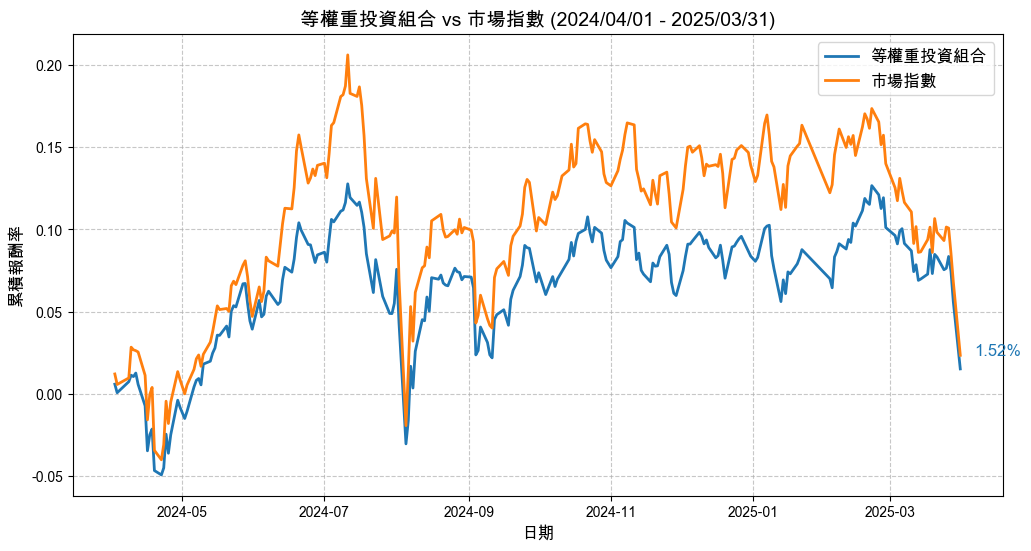

In [42]:
# 主程式流程
if __name__ == "__main__":
    # 載入資料
    stock_prices, market_returns, risk_free_rate, ff_factors = load_real_data()
    
    if stock_prices is not None:
        # 執行回測
        results = backtest_equal_weight_portfolio(stock_prices, market_returns, risk_free_rate, ff_factors)
        
        # 印出績效指標
        print("\n===== 投資組合績效指標 =====")
        for k, v in results['performance_metrics'].items():
            print(f"{k}: {v:.4f}")
        
        # 畫累積報酬率圖
        plot_cumulative_returns(results['portfolio_cumulative_returns'], results['market_cumulative_returns'])


In [ ]:
# 公式列表 沒用到

# 累積報酬
def cumreturn(daily_return):
    return (1 + daily_return).prod() - 1

# 年化報酬率
def ann_ret(daily_return): 
    return (1 + cumreturn(daily_return)) ** (252 / len(daily_return)) - 1

# 年化標準差
def ann_std(daily_return):
    return daily_return.std() * np.sqrt(252)

# sharpe ratio
def sharpe_ratio(daily_return,RF):
    excess = daily_return - RF / 100
    sharpe = excess.mean() / daily_return.std() * np.sqrt(252)
    return sharpe

# 最大回檔比率
def max_drawdown(daily_reurn):
    cum_curve = (1 + daily_reurn).cumprod()
    max_dd = cum_curve.cummax() - cum_curve
    max_dd_pct = max_dd.max() / cum_curve.cummax().max()
    return max_dd_pct

def five_factors_model(daily_return,df):
    X = df[["MKT", "SMB", "HML", "RMW", "CMA"]]
    y = daily_return - df["RF"] / 100
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    alpha = model.params["const"] * 252
    return alpha

# 崔娜比率
def Treynor_Ratio(daily_return,df):
    beta = linregress(df["MKT"], daily_return).slope
    excess = daily_return - RF / 100
    treynor = excess.mean() / beta if beta != 0 else np.nan
    return treynor

# 資訊比率
def Information_Ratio(daily_return,df):
    tracking_error = (daily_return - df["MKT"]).std() * np.sqrt(252)
    info_ratio = (daily_return - df["MKT"]).mean() / tracking_error
    return info_ratio

# 索丁諾比率
def Sortino_Ratio(daily_return):
    downside_std = daily_return[daily_return < 0].std() * np.sqrt(252)
    excess = daily_return - RF / 100
    sortino = excess.mean() / downside_std if downside_std != 0 else np.nan
    return sortino

In [ ]:
# 安裝必要的套件
!pip install kaggle xgboost

# # 設定Kaggle API憑證
# from google.colab import files
# files.upload()  # 上傳你的kaggle.json檔案

# 設定Kaggle API環境
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 下載資料集
!kaggle datasets download -d vanpatangan/readmission-dataset
!unzip readmission-dataset.zip

In [4]:
!pip install xgboost

In [5]:
# 載入必要的庫
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
# data = pd.read_csv('readmission_dataset_5000.csv')

train_data = pd.read_csv('/Users/huangdejin/Downloads/archive/train_df.csv')
test_data = pd.read_csv('/Users/huangdejin/Downloads/archive/test_df.csv')
data = pd.concat([train_data, test_data], ignore_index=True)

# 資料前處理
# 檢查缺失值
print("缺失值檢查：\n", data.isnull().sum())

# 將類別變量轉為數值
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'readmission':  # 目標變量不轉換
        data[col] = le.fit_transform(data[col])

# 將目標變量轉為二元標籤（1表示30天內再入院，0表示無）
data['readmission'] = data['readmission'].apply(lambda x: 1 if x == 'Yes' else 0)

# 特徵和目標變量
X = data.drop('readmission', axis=1)
y = data['readmission']

# 分割訓練和測試資料（5000筆訓練，2000筆測試）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2000, train_size=5000, random_state=42)

# 初始化XGBoost模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# 訓練模型
xgb_model.fit(X_train, y_train)

# 預測
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"模型準確率: {accuracy:.4f}")
print(f"ROC AUC 分數: {roc_auc:.4f}")
print("\n分類報告：\n", classification_report(y_test, y_pred))

# 特徵重要性圖
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance.png')
plt.show()

# 儲存模型
xgb_model.save_model('xgboost_readmission_model.json')

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
python hospital_readmission_xgboost_local.py

In [13]:
pip install xgboost==2.0.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install xgboost --verbose

Using pip 23.1.2 from /Users/huangdejin/anaconda3/lib/python3.11/site-packages/pip (python 3.11)


In [10]:
pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
# 確保 'readmission_dataset_5000.csv' 在你的 VS Code 專案目錄中
data = pd.read_csv('readmission_dataset_5000.csv')

# 資料前處理
# 檢查缺失值
print("缺失值檢查：\n", data.isnull().sum())

# 將類別變量轉為數值
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'readmission':  # 目標變量不轉換
        data[col] = le.fit_transform(data[col])

# 將目標變量轉為二元標籤（1表示30天內再入院，0表示無）
data['readmission'] = data['readmission'].apply(lambda x: 1 if x == 'Yes' else 0)

# 特徵和目標變量
X = data.drop('readmission', axis=1)
y = data['readmission']

# 分割訓練和測試資料（5000筆訓練，2000筆測試）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2000, train_size=5000, random_state=42)

# 初始化XGBoost模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# 訓練模型
xgb_model.fit(X_train, y_train)

# 預測
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"模型準確率: {accuracy:.4f}")
print(f"ROC AUC 分數: {roc_auc:.4f}")
print("\n分類報告：\n", classification_report(y_test, y_pred))

# 特徵重要性圖
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance.png')
plt.show()

# 儲存模型
xgb_model.save_model('xgboost_readmission_model.json')

FileNotFoundError: [Errno 2] No such file or directory: 'readmission_dataset_5000.csv'

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取訓練和測試資料
train_data = pd.read_csv('/Users/huangdejin/Downloads/archive/train_df.csv')
test_data = pd.read_csv('/Users/huangdejin/Downloads/archive/test_df.csv')

# 資料前處理
# 檢查缺失值
print("訓練資料缺失值檢查：\n", train_data.isnull().sum())
print("\n測試資料缺失值檢查：\n", test_data.isnull().sum())

# 將類別變量轉為數值（對訓練和測試資料）
le = LabelEncoder()
categorical_cols = train_data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != 'readmission':  # 目標變量不轉換
        # 合併訓練和測試資料以確保一致的編碼
        combined = pd.concat([train_data[col], test_data[col]], axis=0)
        le.fit(combined)
        train_data[col] = le.transform(train_data[col])
        test_data[col] = le.transform(test_data[col])

# 將目標變量轉為二元標籤（1表示30天內再入院，0表示無）
train_data['readmission'] = train_data['readmission'].apply(lambda x: 1 if x == 'Yes' else 0)
test_data['readmission'] = test_data['readmission'].apply(lambda x: 1 if x == 'Yes' else 0)

# 特徵和目標變量
X_train = train_data.drop('readmission', axis=1)
y_train = train_data['readmission']
X_test = test_data.drop('readmission', axis=1)
y_test = test_data['readmission']

# 確認數據形狀
print(f"\n訓練資料形狀: {X_train.shape}")
print(f"測試資料形狀: {X_test.shape}")

# 初始化XGBoost模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# 訓練模型
xgb_model.fit(X_train, y_train)

# 預測
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n模型準確率: {accuracy:.4f}")
print(f"ROC AUC 分數: {roc_auc:.4f}")
print("\n分類報告：\n", classification_report(y_test, y_pred))

# 特徵重要性圖
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance.png')
plt.show()

# 儲存模型
xgb_model.save_model('xgboost_readmission_model.json')

訓練資料缺失值檢查：
 age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

測試資料缺失值檢查：
 age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
dtype: int64


KeyError: 'readmission'

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取訓練和測試資料
train_data = pd.read_csv('/Users/huangdejin/Downloads/archive/train_df.csv')
test_data = pd.read_csv('/Users/huangdejin/Downloads/archive/test_df.csv')

# 打印欄位名稱和前幾行資料以檢查結構
print("訓練資料欄位：\n", train_data.columns)
print("\n測試資料欄位：\n", test_data.columns)
print("\n訓練資料前5行：\n", train_data.head())
print("\n測試資料前5行：\n", test_data.head())

# 定義目標欄位（請根據實際欄位名稱修改）
TARGET_COLUMN = 'readmission'  # 替換為實際目標欄位名稱，例如 'readmitted' 或 'target'

# 檢查目標欄位是否存在
if TARGET_COLUMN not in train_data.columns or TARGET_COLUMN not in test_data.columns:
    raise KeyError(f"目標欄位 '{TARGET_COLUMN}' 在數據集中不存在，請檢查欄位名稱！")

# 資料前處理
# 檢查缺失值
print("\n訓練資料缺失值檢查：\n", train_data.isnull().sum())
print("\n測試資料缺失值檢查：\n", test_data.isnull().sum())

# 將類別變量轉為數值（對訓練和測試資料）
le = LabelEncoder()
categorical_cols = train_data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != TARGET_COLUMN:  # 目標變量不轉換
        # 合併訓練和測試資料以確保一致的編碼
        combined = pd.concat([train_data[col], test_data[col]], axis=0)
        le.fit(combined)
        train_data[col] = le.transform(train_data[col])
        test_data[col] = le.transform(test_data[col])

# 將目標變量轉為二元標籤（根據實際值調整）
# 假設目標值為 "Yes"/"No"，如果為 1/0 或其他格式，請修改
if train_data[TARGET_COLUMN].dtype == 'object':
    train_data[TARGET_COLUMN] = train_data[TARGET_COLUMN].apply(lambda x: 1 if x.lower() == 'yes' else 0)
    test_data[TARGET_COLUMN] = test_data[TARGET_COLUMN].apply(lambda x: 1 if x.lower() == 'yes' else 0)
else:
    # 假設目標值已為 1/0
    train_data[TARGET_COLUMN] = train_data[TARGET_COLUMN].astype(int)
    test_data[TARGET_COLUMN] = test_data[TARGET_COLUMN].astype(int)

# 特徵和目標變量
X_train = train_data.drop(TARGET_COLUMN, axis=1)
y_train = train_data[TARGET_COLUMN]
X_test = test_data.drop(TARGET_COLUMN, axis=1)
y_test = test_data[TARGET_COLUMN]

# 確認數據形狀
print(f"\n訓練資料形狀: {X_train.shape}")
print(f"測試資料形狀: {X_test.shape}")

# 初始化XGBoost模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# 訓練模型
xgb_model.fit(X_train, y_train)

# 預測
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n模型準確率: {accuracy:.4f}")
print(f"ROC AUC 分數: {roc_auc:.4f}")
print("\n分類報告：\n", classification_report(y_test, y_pred))

# 特徵重要性圖
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance.png')
plt.show()

# 儲存模型
xgb_model.save_model('xgboost_readmission_model.json')

訓練資料欄位：
 Index(['age', 'gender', 'primary_diagnosis', 'num_procedures',
       'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted'],
      dtype='object')

測試資料欄位：
 Index(['age', 'gender', 'primary_diagnosis', 'num_procedures',
       'days_in_hospital', 'comorbidity_score', 'discharge_to'],
      dtype='object')

訓練資料前5行：
    age  gender primary_diagnosis  num_procedures  days_in_hospital  \
0   69    Male     Heart Disease               1                 2   
1   32  Female              COPD               2                13   
2   89    Male          Diabetes               1                 7   
3   78    Male              COPD               9                 2   
4   38    Male          Diabetes               6                 4   

   comorbidity_score              discharge_to  readmitted  
0                  1          Home Health Care           0  
1                  2   Rehabilitation Facility           0  
2                  1                      Home      

KeyError: "目標欄位 'readmission' 在數據集中不存在，請檢查欄位名稱！"

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

# 讀取訓練和測試資料
train_data = pd.read_csv('/Users/huangdejin/Downloads/archive/train_df.csv')
test_data  = pd.read_csv('/Users/huangdejin/Downloads/archive/test_df.csv')

# 檢查欄位
print("訓練集欄位：", train_data.columns.tolist())
print("測試集欄位：", test_data.columns.tolist())

# 正確的目標欄位
TARGET_COLUMN = 'readmitted'

# 檢查目標欄位是否存在
if TARGET_COLUMN not in train_data.columns:
    raise KeyError(f"目標欄位 '{TARGET_COLUMN}' 在訓練集不存在！")
if TARGET_COLUMN not in test_data.columns:
    # 若測試集沒有 readmitted，可先合併或另行處理；這裡假設測試集也有同名欄位
    print("注意：測試集內不含目標欄位 'readmitted'，僅做特徵預測。")

# Label Encoding：將所有 object 類別欄位轉成 int
le = LabelEncoder()
for col in train_data.select_dtypes(include=['object']).columns:
    if col == TARGET_COLUMN:
        continue
    combined = pd.concat([train_data[col], test_data[col]], axis=0)
    le.fit(combined)
    train_data[col] = le.transform(train_data[col])
    test_data[col]  = le.transform(test_data[col])

# 如果 readmitted 不是 0/1，將其轉成二元
if train_data[TARGET_COLUMN].dtype == 'object':
    train_data[TARGET_COLUMN] = train_data[TARGET_COLUMN].apply(lambda x: 1 if x == '<30' else 0)
    test_data[TARGET_COLUMN]  = test_data[TARGET_COLUMN].apply(lambda x: 1 if x == '<30' else 0)
else:
    train_data[TARGET_COLUMN] = train_data[TARGET_COLUMN].astype(int)
    test_data[TARGET_COLUMN]  = test_data[TARGET_COLUMN].astype(int)

# 分離特徵與目標
X_train = train_data.drop(TARGET_COLUMN, axis=1)
y_train = train_data[TARGET_COLUMN]
X_test  = test_data.drop(TARGET_COLUMN, axis=1)
y_test  = test_data[TARGET_COLUMN]

print(f"訓練集形狀: {X_train.shape}, 測試集形狀: {X_test.shape}")

# 建立並訓練 XGBoost 模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 模型預測與評估
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"\n模型準確率: {accuracy:.4f}")
print(f"ROC AUC 分數: {roc_auc:.4f}")
print("\n分類報告：")
print(classification_report(y_test, y_pred))

# 繪製並儲存特徵重要性圖
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 儲存模型到檔案
xgb_model.save_model('xgboost_readmission_model.json')
print("模型已儲存為 xgboost_readmission_model.json，特徵重要性圖儲存為 feature_importance.png")


訓練集欄位： ['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted']
測試集欄位： ['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to']
注意：測試集內不含目標欄位 'readmitted'，僅做特徵預測。


KeyError: 'readmitted'

欄位： ['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted']
訓練集形狀: (4000, 7), 測試集形狀: (1000, 7)

模型準確率: 1.0000
ROC AUC 分數: nan

分類報告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


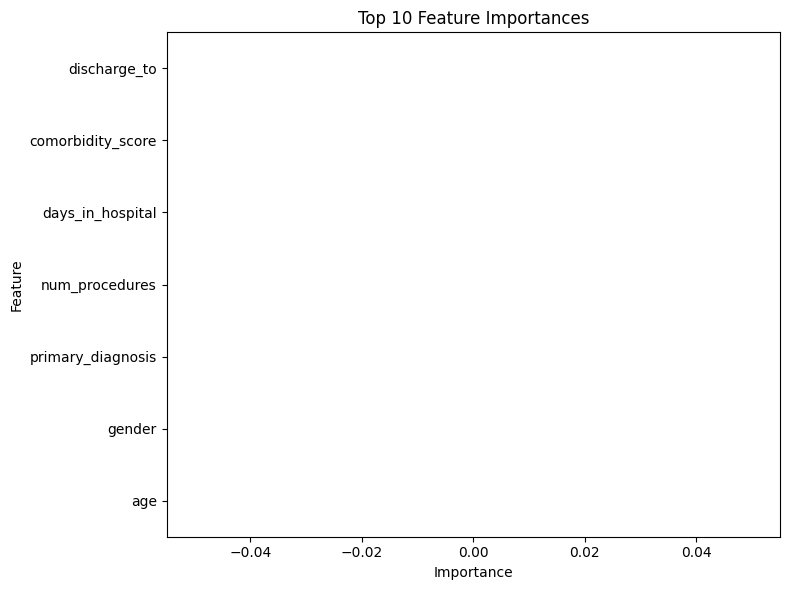


模型已儲存為 xgboost_readmission_model.json


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

# 1. 讀取資料（只有 train_df.csv，裡面含有 readmitted 標籤）
df = pd.read_csv('/Users/huangdejin/Downloads/archive/train_df.csv')

# 2. 檢查欄位
print("欄位：", df.columns.tolist())
# 確認 readmitted 在欄位中
assert 'readmitted' in df.columns, "找不到 readmitted 欄位！"

# 3. Label Encoding：將所有 object 類別欄位轉成 int（除了 readmitted）
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if col == 'readmitted':
        continue
    df[col] = le.fit_transform(df[col])

# 4. 目標轉 0/1：'<30' → 1，其他 → 0
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 5. 切分特徵與目標
X = df.drop('readmitted', axis=1)
y = df['readmitted']

# 6. 80/20 隨機切分成訓練集/測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"訓練集形狀: {X_train.shape}, 測試集形狀: {X_test.shape}")

# 7. 建立並訓練 XGBoost 模型
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# 8. 模型預測與評估
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"\n模型準確率: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC 分數: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\n分類報告：")
print(classification_report(y_test, y_pred))

# 9. 繪製並儲存特徵重要性圖
plt.figure(figsize=(8, 6))
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# 10. 儲存模型
model.save_model('xgboost_readmission_model.json')
print("\n模型已儲存為 xgboost_readmission_model.json")
